In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [44]:
# Configure plotting style
plt.style.use('default')
colors = plt.cm.tab10(np.linspace(0, 1, 10))

In [45]:
# File path 
file_path = r"D:\Master in Geoinformatics\Semester 2\GNSS Survey Mapping\Lab\Lab 2\ringo\Excel.xlsx"


In [46]:
# Constellation mapping
constellations = ['G', 'R', 'E', 'C', 'J']
constellation_names = ['GPS', 'GLONASS', 'Galileo', 'BeiDou', 'QZSS']

In [47]:
# Convert DOY to actual dates (assuming year 2025)
year = 2025
base_date = datetime(year, 1, 1)

In [48]:
# Read the Excel file
df = pd.read_excel(file_path)

In [49]:
# Create a mapping from DOY to actual date
df['Date'] = df['Day'].apply(lambda x: base_date + timedelta(days=int(x)-1))
df['Date_str'] = df['Date'].dt.strftime('%Y-%m-%d')

In [50]:
# Display basic info
print("Data Overview:")
print(f"Total rows: {len(df)}")
print(f"Year: {year}")
print(f"Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Stations: {df['Station'].nunique()}")
print(f"Constellations: {df['SYS'].nunique()}")

Data Overview:
Total rows: 85
Year: 2025
Date range: 2025-07-16 to 2025-07-18
Stations: 6
Constellations: 6


In [51]:
# Create output directory for plots
output_dir = Path(r"D:\Master in Geoinformatics\Semester 2\GNSS Survey Mapping\Lab\Lab 2\ringo\multipath_plots")
output_dir.mkdir(exist_ok=True)
print(f"\nPlots will be saved to: {output_dir}")


Plots will be saved to: D:\Master in Geoinformatics\Semester 2\GNSS Survey Mapping\Lab\Lab 2\ringo\multipath_plots


In [52]:
# Get unique stations
stations = df['Station'].unique()
days = sorted(df['Day'].unique())
dates = [base_date + timedelta(days=int(d)-1) for d in days]

print(f"\nStations: {list(stations)}")
print(f"Days (DOY): {list(days)}")
print(f"Corresponding dates: {[d.strftime('%Y-%m-%d') for d in dates]}")


Stations: ['BHPL00IND', 'BOMB', 'DRDN00IND', 'IISC00IND', 'MANI', 'ROPA']
Days (DOY): [np.int64(197), np.int64(198), np.int64(199)]
Corresponding dates: ['2025-07-16', '2025-07-17', '2025-07-18']


Processing station: BHPL00IND
Days in data (DOY): [197 198 199]
Dates: ['2025-07-16', '2025-07-17', '2025-07-18']

Observations per constellation:
  GPS (G): 3 observations
  GLONASS (R): 3 observations
  Galileo (E): 3 observations
  BeiDou (C): 0 observations
  QZSS (J): 3 observations


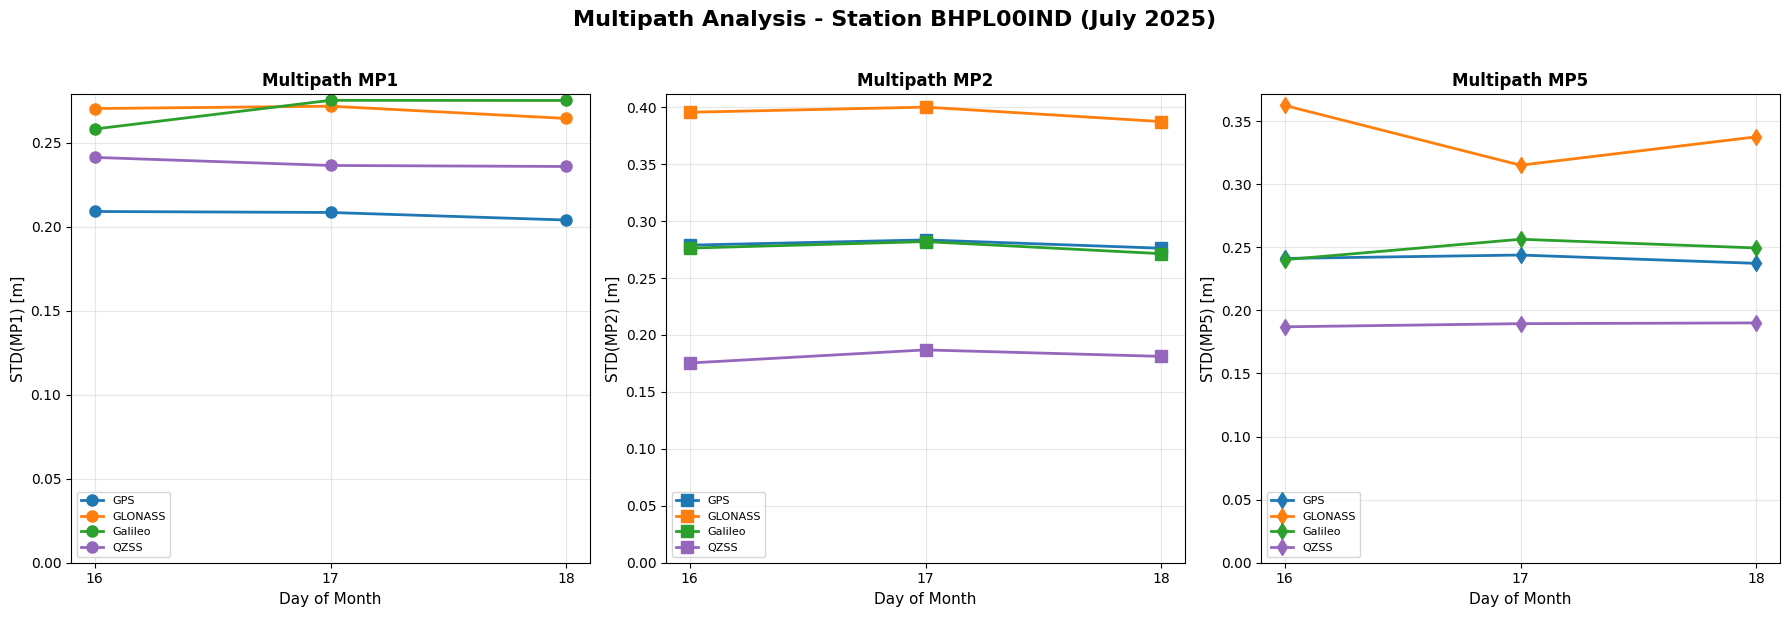


 Combined plot (1x3) saved for BHPL00IND as BHPL00IND_all_mp.png
Processing station: BOMB
Days in data (DOY): [197 198 199]
Dates: ['2025-07-16', '2025-07-17', '2025-07-18']

Observations per constellation:
  GPS (G): 3 observations
  GLONASS (R): 3 observations
  Galileo (E): 3 observations
  BeiDou (C): 3 observations
  QZSS (J): 3 observations


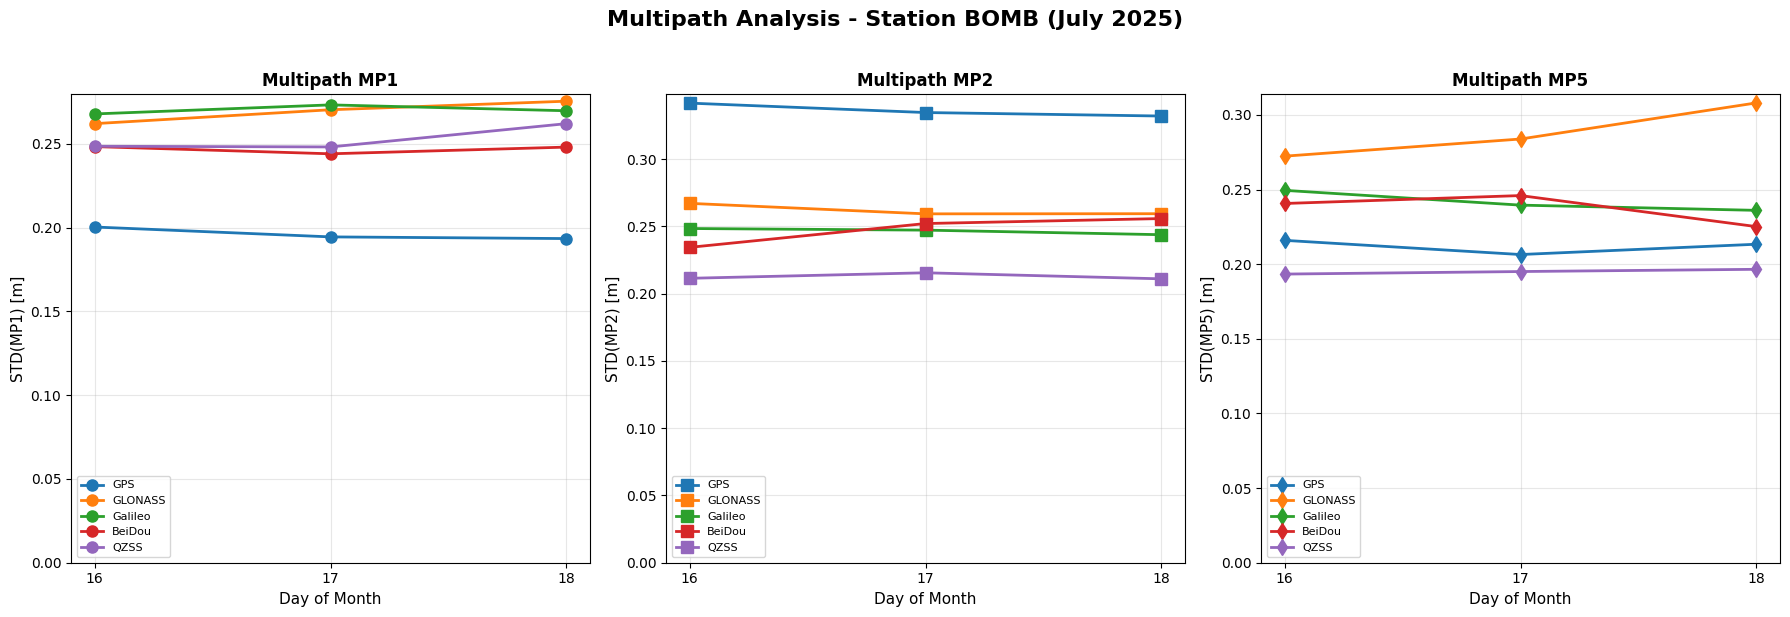


 Combined plot (1x3) saved for BOMB as BOMB_all_mp.png
Processing station: DRDN00IND
Days in data (DOY): [197 198 199]
Dates: ['2025-07-16', '2025-07-17', '2025-07-18']

Observations per constellation:
  GPS (G): 3 observations
  GLONASS (R): 3 observations
  Galileo (E): 3 observations
  BeiDou (C): 0 observations
  QZSS (J): 3 observations


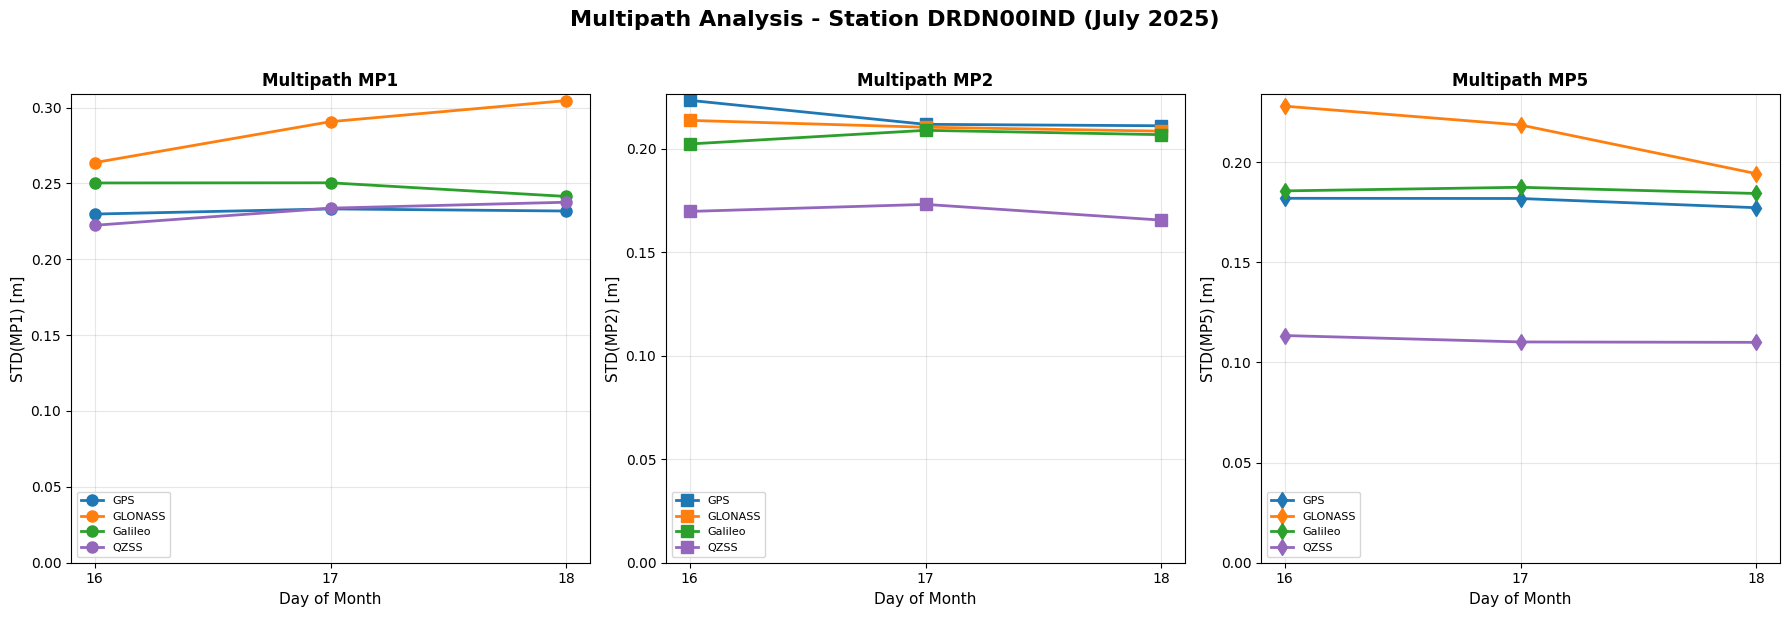


 Combined plot (1x3) saved for DRDN00IND as DRDN00IND_all_mp.png
Processing station: IISC00IND
Days in data (DOY): [197 198 199]
Dates: ['2025-07-16', '2025-07-17', '2025-07-18']

Observations per constellation:
  GPS (G): 3 observations
  GLONASS (R): 3 observations
  Galileo (E): 3 observations
  BeiDou (C): 3 observations
  QZSS (J): 3 observations


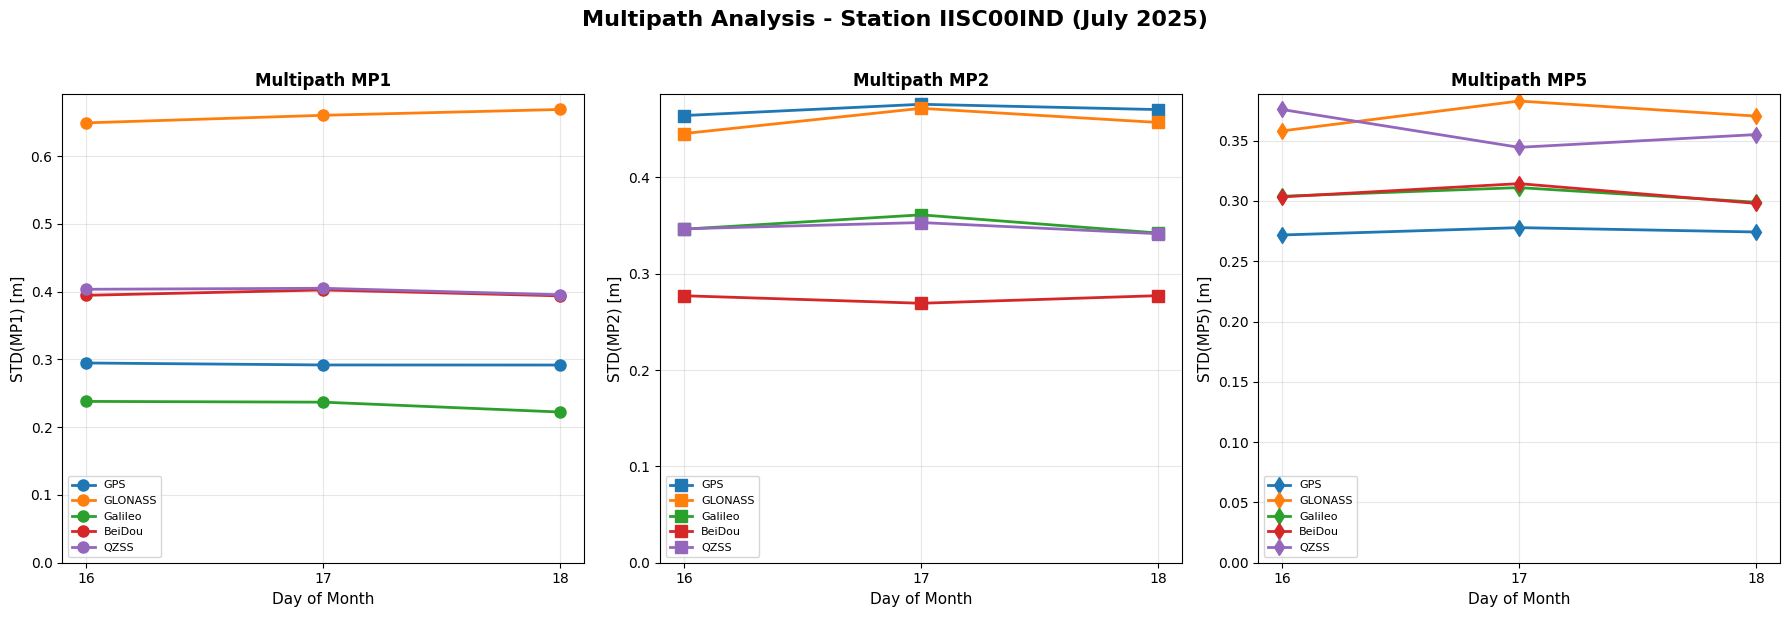


 Combined plot (1x3) saved for IISC00IND as IISC00IND_all_mp.png
Processing station: MANI
Days in data (DOY): [197 198 199]
Dates: ['2025-07-16', '2025-07-17', '2025-07-18']

Observations per constellation:
  GPS (G): 3 observations
  GLONASS (R): 3 observations
  Galileo (E): 3 observations
  BeiDou (C): 3 observations
  QZSS (J): 3 observations


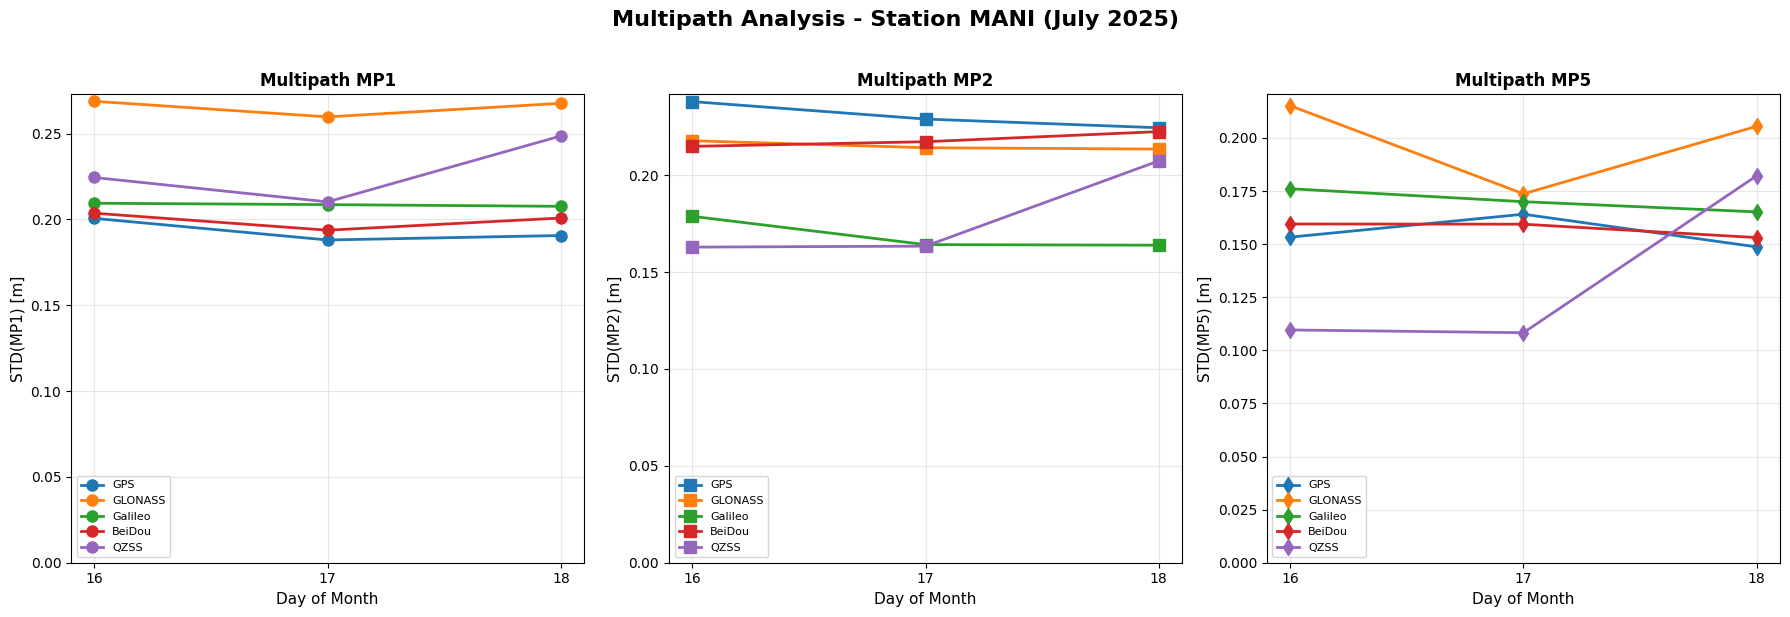


 Combined plot (1x3) saved for MANI as MANI_all_mp.png
Processing station: ROPA
Days in data (DOY): [197 198 199]
Dates: ['2025-07-16', '2025-07-17', '2025-07-18']

Observations per constellation:
  GPS (G): 3 observations
  GLONASS (R): 3 observations
  Galileo (E): 3 observations
  BeiDou (C): 3 observations
  QZSS (J): 3 observations


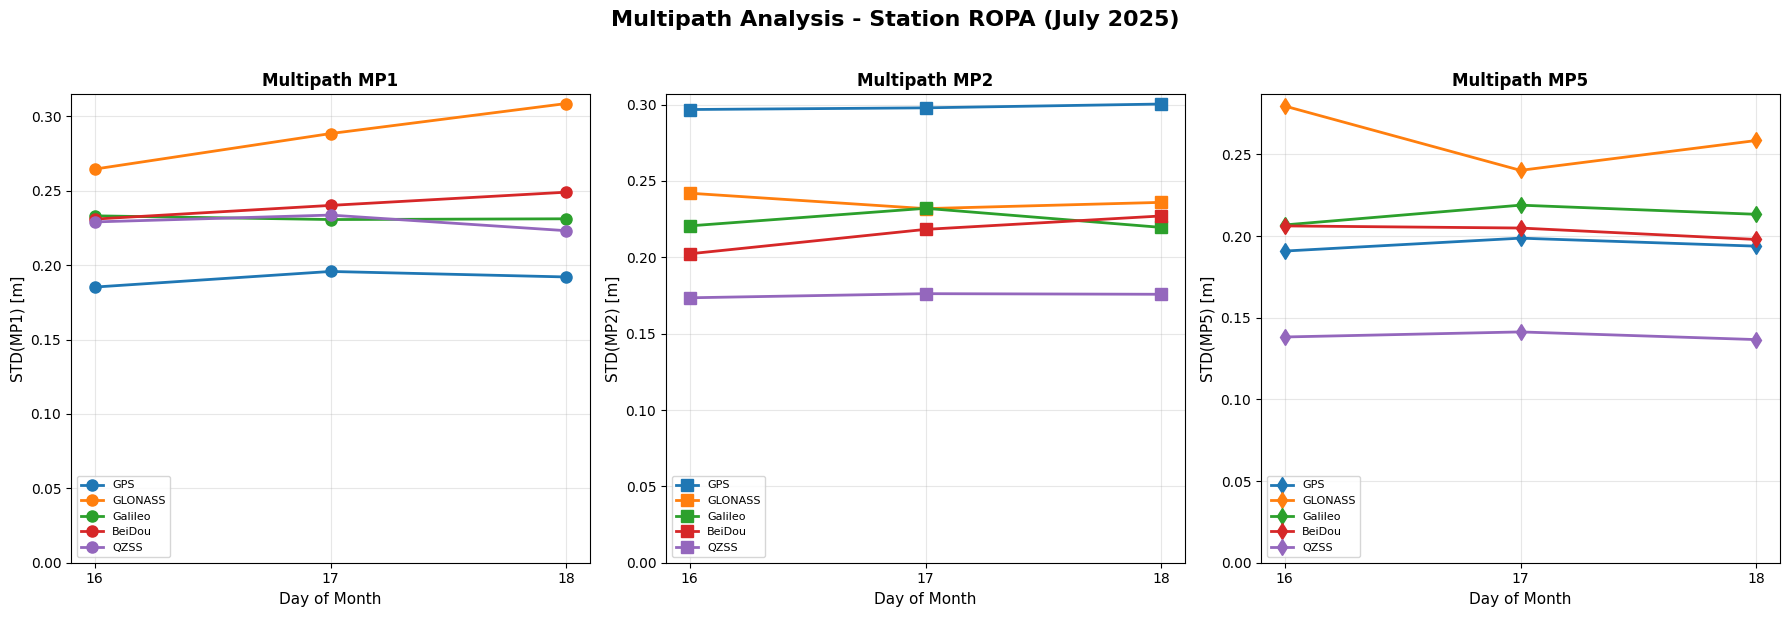


 Combined plot (1x3) saved for ROPA as ROPA_all_mp.png
Plots are saved in: D:\Master in Geoinformatics\Semester 2\GNSS Survey Mapping\Lab\Lab 2\ringo\multipath_plots


In [53]:
# Process each station
for station in stations:
    print(f"Processing station: {station}")
    
    # Filter data for this station
    station_data = df[df['Station'] == station].copy()
    
    # Extract variables
    DOY = station_data['Day'].values
    DATES = station_data['Date'].values
    SYS = station_data['SYS'].astype(str).values
    MP1 = station_data['STD(MP1)'].values
    MP2 = station_data['STD(MP2)'].values
    MP5 = station_data['STD(MP5)'].values
    
    # Unique DOY and corresponding dates
    unique_days = np.unique(DOY)
    unique_dates = [base_date + timedelta(days=int(d)-1) for d in unique_days]
    
    # Get month and year for title
    month_year = unique_dates[0].strftime('%B %Y')
    print(f"Days in data (DOY): {unique_days}")
    print(f"Dates: {[d.strftime('%Y-%m-%d') for d in unique_dates]}")
    
    # Prepare arrays
    MP1mat = np.full((len(unique_days), len(constellations)), np.nan)
    MP2mat = np.full((len(unique_days), len(constellations)), np.nan)
    MP5mat = np.full((len(unique_days), len(constellations)), np.nan)
    
    # Fill matrices
    print("\nObservations per constellation:")
    for i, const in enumerate(constellations):
        idx = SYS == const
        count = np.sum(idx)
        print(f"  {constellation_names[i]} ({const}): {count} observations")
        
        for j, d in enumerate(unique_days):
            row = idx & (DOY == d)
            if np.any(row):
                MP1mat[j, i] = MP1[row][0]
                MP2mat[j, i] = MP2[row][0]
                MP5mat[j, i] = MP5[row][0]
    
    # Create a single figure with 3 subplots in one row (1x3) 
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
    
    # MP1 subplot (first column)
    ax = axes[0]
    ax.set_facecolor('white')
    ax.grid(True, linestyle='-', alpha=0.3)
    ax.set_axisbelow(True)
    
    for i in range(len(constellations)):
        if not np.all(np.isnan(MP1mat[:, i])):
            ax.plot(unique_dates, MP1mat[:, i], '-o', linewidth=2, markersize=8, 
                    color=colors[i], label=constellation_names[i])
    
    # Format x-axis with only day numbers
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
    
    ax.set_xlabel('Day of Month', fontsize=11)
    ax.set_ylabel('STD(MP1) [m]', fontsize=11)
    ax.set_title(f'Multipath MP1', fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    ax.set_ylim(bottom=0)
    ax.legend(loc='best', fontsize=8, ncol=1)
    
    # MP2 subplot (second column)
    ax = axes[1]
    ax.set_facecolor('white')
    ax.grid(True, linestyle='-', alpha=0.3)
    ax.set_axisbelow(True)
    
    for i in range(len(constellations)):
        if not np.all(np.isnan(MP2mat[:, i])):
            ax.plot(unique_dates, MP2mat[:, i], '-s', linewidth=2, markersize=8, 
                    color=colors[i], label=constellation_names[i])
    
    # Format x-axis with only day numbers
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
    
    ax.set_xlabel('Day of Month', fontsize=11)
    ax.set_ylabel('STD(MP2) [m]', fontsize=11)
    ax.set_title(f'Multipath MP2', fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    ax.set_ylim(bottom=0)
    ax.legend(loc='best', fontsize=8, ncol=1)
    
    # MP5 subplot (third column)
    ax = axes[2]
    ax.set_facecolor('white')
    ax.grid(True, linestyle='-', alpha=0.3)
    ax.set_axisbelow(True)
    
    for i in range(len(constellations)):
        if not np.all(np.isnan(MP5mat[:, i])):
            ax.plot(unique_dates, MP5mat[:, i], '-d', linewidth=2, markersize=8, 
                    color=colors[i], label=constellation_names[i])
    
    # Format x-axis with only day numbers
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
    
    ax.set_xlabel('Day of Month', fontsize=11)
    ax.set_ylabel('STD(MP5) [m]', fontsize=11)
    ax.set_title(f'Multipath MP5', fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    ax.set_ylim(bottom=0)
    ax.legend(loc='best', fontsize=8, ncol=1)
    
    # Add main title for the entire figure with month and year
    plt.suptitle(f'Multipath Analysis - Station {station} ({month_year})', fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig(output_dir / f'{station}_all_mp.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n Combined plot (1x3) saved for {station} as {station}_all_mp.png")
print(f"Plots are saved in: {output_dir}")